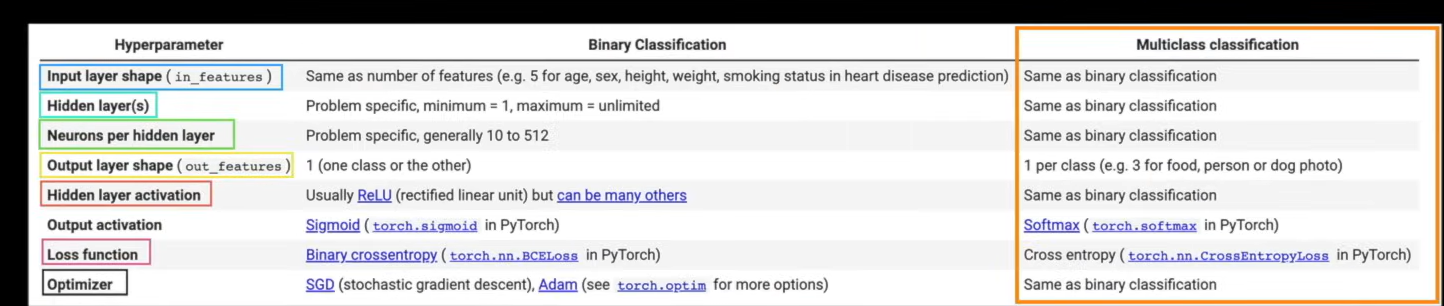

### 8.1 Creating a toy multi-class dataset

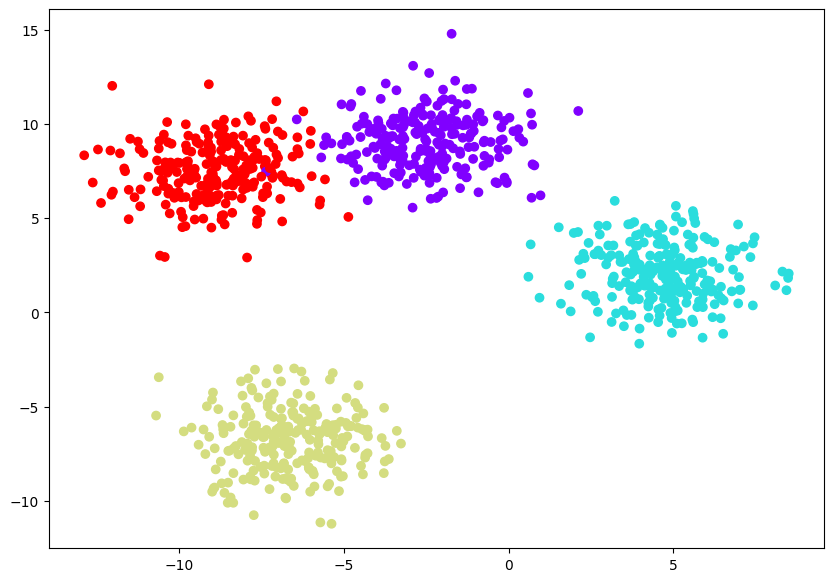

In [1]:
#Import dependencies
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs 
from sklearn.model_selection import train_test_split
from torch import nn
#Hyperparameters for data

NUM_CLASSES = 4 
NUM_FEATURES = 2 
RANDOM_SEED = 42 

#create multi-class data
X_blob, y_blob = make_blobs(n_samples= 1000,n_features= NUM_FEATURES,centers = NUM_CLASSES,cluster_std=1.5 ,random_state=RANDOM_SEED)
#Turn data into tensors                                                                    randomizes the data
X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.float)
#Split into train and test

X_blob_train , X_blob_test , y_blob_train,y_blob_test = train_test_split(X_blob,y_blob,test_size=0.2,random_state=42)


#Plot the data
plt.figure(figsize=(10,7))
plt.scatter(X_blob[:,0] , X_blob[:,1], c=y_blob,cmap=plt.cm.rainbow)
plt.show()


### 8.2 Building a multi-class classification model in Pytorch

In [2]:
#device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device



'cuda'

In [14]:
#Building a multiclass classification model
class Blobmodel(nn.Module):
    def __init__(self,input_features,output_features,hidden_units = 8):
        """Initializes multi-class classification model. 
        Args :
            input_features (int): Number of input features to the model
            output_features (int) : Number of output features to the model
            hidden_units (int) : number of hidden units between i/o layres , default 8 
            """
        super().__init__()
        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units,out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features = hidden_units,out_features = output_features)
        )
        def forward(self,x):
            return self.linear_layer_stack(x)

model_4 = Blobmodel(input_features = 2, output_features = 4 ,hidden_units = 8)
model_4.to(device)
model_4

Blobmodel(
  (linear_layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
)

In [ ]:
torch.unique(y_blob_train)#how many unique values are present in the dataset

tensor([0., 1., 2., 3.])

In [ ]:
#check the shapes
X_blob_train.shape , y_blob_train.shape

(torch.Size([800, 2]), torch.Size([800]))

In [10]:
# check data type
X_blob_test.dtype,y_blob_train.dtype

(torch.float32, torch.float32)